In [104]:
import numpy as np

### Speicfy setup of qubits

In [105]:
rng = np.random.default_rng(1234)

In [106]:
# Basic utilities
def normalise(psi):
    norm = np.linalg.norm(psi)
    if norm == 0:
        return psi
    return psi / norm

def dagger(psi):
    return np.conjugate(psi.T)

def density_matrix(psi):
    psi = normalise(psi)
    return np.outer(psi, dagger(psi))

def tensor_product(A,B):
    return np.kron(A,B)

def depolarise(rho, p): # alters the density matrix rho with depolarising noise p
    d = rho.shape[0]
    I = np.eye(d)
    return (1 - p) * rho + p * I / d

state_0 = np.array([1,0])
state_1 = np.array([0,1])


#### Trial 2-qubit state

In [107]:
# Use bell state as a trial

state_bell = normalise(tensor_product(state_0, state_0) + tensor_product(state_1, state_1))
rho_bell = density_matrix(state_bell)

In [108]:
print(rho_bell)
print(np.trace(rho_bell))  # Should be 1

[[0.5 0.  0.  0.5]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.5 0.  0.  0.5]]
1.0000000000000002


Define POVM elements to measure in Z basis

In [109]:
Z = [[1,0],[0,-1]]
ZZ = tensor_product(Z,Z)
print(ZZ)

[[ 1  0  0  0]
 [ 0 -1  0  0]
 [ 0  0 -1  0]
 [ 0  0  0  1]]


Can see from the ZZ matrix that the eigenvalues are +1 (for |00> and |11>) and -1 (for |10> and |01>)

In tomography, you aim to reconstruct the density matrix. Using ZZ gives an eigenvalue [-1,1] simply saying how likely the qubits are to be aligned or misaligned. Projectors (such as |00><00|) give individual outcomes of the ZZ measurement (the entire joint probability distribution).

Projectors and density matrices are visually and mathematically identical, but projectors are used to measure states and density matrices represent prepared states

The POVM is a list of the projectors defined by the eigenstates of the operator, ZZ in this case. This POVM is related to ZZ as we are using its eigenstates as the projectors.

In [110]:
E_00 = density_matrix(tensor_product(state_0, state_0))  # |00><00|
E_01 = density_matrix(tensor_product(state_0, state_1))  # |01><01|
E_10 = density_matrix(tensor_product(state_1, state_0))  # |10><10|
E_11 = density_matrix(tensor_product(state_1, state_1))  # |11><11|

POVM_ZZ = [E_00, E_01, E_10, E_11]

In [111]:
probs = [float(np.trace(rho_bell @ E)) for E in POVM_ZZ]
# Finds probabilities of measuring each outcome in the POVM given the state rho_bell

In [112]:
print(probs)

[0.5000000000000001, 0.0, 0.0, 0.5000000000000001]


Probabilities have come out as expected for Bell State

### Constructing POVMs using X, Y, and Z basis

In [113]:
# The three Pauli matrices

X = np.array([[0, 1],
              [1, 0]], dtype=complex)

Y = np.array([[0, -1j],
              [1j, 0]], dtype=complex)

Z = np.array([[1, 0],
              [0, -1]], dtype=complex)

In [114]:
# States for X basis
states_X = np.linalg.eig(X)[1]
states_Y = np.linalg.eig(Y)[1]
states_Z = np.linalg.eig(Z)[1]

In [115]:
# Define a function to get POVM from two sets of basis states
def get_POVM(A,B):
    POVM = []
    E_0 = density_matrix(tensor_product(A[0], B[0]))
    E_1 = density_matrix(tensor_product(A[0], B[1]))
    E_2 = density_matrix(tensor_product(A[1], B[0]))
    E_3 = density_matrix(tensor_product(A[1], B[1]))
    POVM = [E_0, E_1, E_2, E_3]
    return POVM
# Note for future that density_matrix automatically normalises the states

In [116]:
POVM_XX = get_POVM(states_X, states_X)
POVM_XY = get_POVM(states_X, states_Y)
POVM_XZ = get_POVM(states_X, states_Z)
POVM_YX = get_POVM(states_Y, states_X)
POVM_YY = get_POVM(states_Y, states_Y)
POVM_YZ = get_POVM(states_Y, states_Z)
POVM_ZX = get_POVM(states_Z, states_X)
POVM_ZY = get_POVM(states_Z, states_Y)
POVM_ZZ = get_POVM(states_Z, states_Z)

In [117]:
# Check that POVMs sum to identity
print(sum(POVM_XX).round(6))

[[ 1.+0.j  0.+0.j -0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [-0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  1.+0.j]]


In [118]:
def get_probs(rho, POVM):
    ps = np.array([float(np.real(np.trace(rho @ E))) for E in POVM])
    ps = np.clip(ps, 1e-15, 1.0)
    ps /= np.sum(ps)  # Normalise
    return ps

In [119]:
# introduce noise to rho_bell
rho_bell_noisy = depolarise(rho_bell, 0.1)

In [120]:
probs_XX = get_probs(rho_bell_noisy, POVM_XX)
probs_XY = get_probs(rho_bell_noisy, POVM_XY)
probs_XZ = get_probs(rho_bell_noisy, POVM_XZ)
probs_YX = get_probs(rho_bell_noisy, POVM_YX)
probs_YY = get_probs(rho_bell_noisy, POVM_YY)
probs_YZ = get_probs(rho_bell_noisy, POVM_YZ)
probs_ZX = get_probs(rho_bell_noisy, POVM_ZX)
probs_ZY = get_probs(rho_bell_noisy, POVM_ZY)
probs_ZZ = get_probs(rho_bell_noisy, POVM_ZZ)

**We constructed all nine two-qubit product-Pauli POVMs (XX, XY, …, ZZ) and used them to compute, via Born’s rule, the exact theoretical measurement probabilities for each outcome of the Bell state.**

### Generating noisy bell state shots - aim to reconstruct Bell State density matrix from these

In [121]:
# Generate with gaussian noise to start with

def generate_noisy_shot(probs, noise_level):
    noisy_probs = probs + rng.normal(0, noise_level, size=len(probs))
    noisy_probs = np.clip(noisy_probs, 0, None)  # Ensure no negative probabilities
    noisy_probs /= np.sum(noisy_probs)  # Renormalise
    shot = rng.multinomial(1, noisy_probs) # Draw probabilistic shots
    return shot
# Noise is remade for each shot to simulate noise in a real experiment

In [122]:
# trial for ZZ POVM
N_shots = 100
noise_level = 0.2  # Standard deviation of Gaussian noise
shots_ZZ = [generate_noisy_shot(probs_ZZ, noise_level) for _ in range(N_shots)]

In [123]:
measured_probs_ZZ = np.mean(shots_ZZ, axis=0)
print("Theoretical probs ZZ:", probs_ZZ)
print("Measured probs ZZ:", measured_probs_ZZ)

Theoretical probs ZZ: [0.475 0.025 0.025 0.475]
Measured probs ZZ: [0.37 0.1  0.07 0.46]


In [124]:
shots_XX = [generate_noisy_shot(probs_XX, noise_level) for _ in range(N_shots)]
shots_XY = [generate_noisy_shot(probs_XY, noise_level) for _ in range(N_shots)]
shots_XZ = [generate_noisy_shot(probs_XZ, noise_level) for _ in range(N_shots)]
shots_YX = [generate_noisy_shot(probs_YX, noise_level) for _ in range(N_shots)]
shots_YY = [generate_noisy_shot(probs_YY, noise_level) for _ in range(N_shots)]
shots_YZ = [generate_noisy_shot(probs_YZ, noise_level) for _ in range(N_shots)]
shots_ZX = [generate_noisy_shot(probs_ZX, noise_level) for _ in range(N_shots)]
shots_ZY = [generate_noisy_shot(probs_ZY, noise_level) for _ in range(N_shots)]

### Putting things in place to reconstruct density matrix

Use Bayes theroem to reconstruct the state

In [125]:
POVMs = [POVM_XX, POVM_XY, POVM_XZ, POVM_YX, POVM_YY, POVM_YZ, POVM_ZX, POVM_ZY, POVM_ZZ]

In [126]:
counts_XX = np.sum(np.asarray(shots_XX), axis=0)
counts_XY = np.sum(np.asarray(shots_XY), axis=0)
counts_XZ = np.sum(np.asarray(shots_XZ), axis=0)
counts_YX = np.sum(np.asarray(shots_YX), axis=0)
counts_YY = np.sum(np.asarray(shots_YY), axis=0)
counts_YZ = np.sum(np.asarray(shots_YZ), axis=0)
counts_ZX = np.sum(np.asarray(shots_ZX), axis=0)
counts_ZY = np.sum(np.asarray(shots_ZY), axis=0)
counts_ZZ = np.sum(np.asarray(shots_ZZ), axis=0)

In [127]:
counts = [counts_XX, counts_XY, counts_XZ, counts_YX, counts_YY, counts_YZ, counts_ZX, counts_ZY, counts_ZZ]
# Corresponds to the POVMs list order

In [128]:
# Use log likelihood to remove factorials, constant in rho
def log_likelihood(rho, POVMs, counts):
    ll = 0
    for POVM, count in zip(POVMs, counts):
        probs = get_probs(rho, POVM)
        ll += np.sum(count * np.log(probs))
    return ll

In [129]:
# We need a prior, draw random matrix using Ginibre
# Guess lots of priors and find one with the highest likelihood
def random_density_hs():
    G = (np.random.randn(4,4) + 1j*np.random.randn(4,4))/np.sqrt(2.0)
    X = G @ G.conj().T
    return X / X.trace().real

In [130]:
# need to define fidelity between reconstructed solution (rho) and true bell matrix (sigma)
# F = (Trace sqrt( sqrt(sigma) * rho * sqrt(sigma) ) )^2
def fidelity(rho, sigma):
    vals, vecs = np.linalg.eigh(sigma)
    sqrt_sigma = (vecs * np.sqrt(np.clip(vals,0,1))) @ vecs.conj().T # finding root sigma from eigendecomposition
    M = sqrt_sigma @ rho @ sqrt_sigma
    vals_M, _ = np.linalg.eigh((M + M.conj().T) / 2)  # Ensure Hermitian
    return (np.sum(np.sqrt(np.clip(vals_M, 0, np.inf))))**2 # Gives final fidelity

In [131]:
# Define weighted percentiles given how likely each solution is
# Some represent a larger fraction of the posterior probability 
def weighted_percentile(values, weights, quantiles):
    order = np.argsort(values)
    v = np.asarray(values)[order]
    w = np.asarray(weights)[order]
    cdf = np.cumsum(w)
    return np.interp(np.array(quantiles), cdf, v)

In [132]:
rhos = []
log_likes = np.empty(20000, float)

for i in range(20000):
    rho = random_density_hs()
    rhos.append(rho)
    log_likes[i] = log_likelihood(rho, POVMs, counts)
    # Finding log likelihood for the randomly selected priors

max_ll = np.max(log_likes)
weights = np.exp(log_likes - max_ll)
weights /= weights.sum()

Posterior distribution p(rho|D) proportional to p(D|rho)p(rho)
p(rho|D) is probability of rho given data
p(D|rho) is probability of data given rho (likelihood)
p(rho) is the prior

In [133]:
# Get posterior mean density matrix - average rho weighted by likelihood
rho_mean = np.zeros((4,4), complex)
for weight, rho in zip(weights, rhos):
    rho_mean += weight * rho

In [134]:
rho_best = rhos[int(np.argmax(log_likes))]

rho_phi = rho_bell
fidelities = [fidelity(rho, rho_phi) for rho in rhos]
mean_fidelity = np.sum(np.array(fidelities) * weights)
fidelity_credible_interval = weighted_percentile(fidelities, weights, [0.05, 0.95])

In [135]:
np.set_printoptions(precision=6, suppress=True)
print("Posterior mean ρ:\n", rho_mean)
print("\nMAP-ish ρ (best sample):\n", rho_best)
print("True Bell state ρ:\n", rho_bell)
print("Fidelity to |Φ+> (mean, 95% CI):", mean_fidelity, fidelity_credible_interval)

Posterior mean ρ:
 [[ 0.275516+0.j       -0.022314-0.054144j  0.064654-0.004045j
   0.243851-0.012707j]
 [-0.022314+0.054144j  0.137379+0.j        0.00417 +0.080567j
  -0.043237-0.03255j ]
 [ 0.064654+0.004045j  0.00417 -0.080567j  0.145986+0.j
  -0.006034+0.004164j]
 [ 0.243851+0.012707j -0.043237+0.03255j  -0.006034-0.004164j
   0.441119+0.j      ]]

MAP-ish ρ (best sample):
 [[ 0.247867+0.j       -0.025885-0.068895j  0.076786-0.011537j
   0.255752-0.001312j]
 [-0.025885+0.068895j  0.123683+0.j       -0.004065+0.100702j
  -0.045188-0.03571j ]
 [ 0.076786+0.011537j -0.004065-0.100702j  0.160741+0.j
  -0.005727+0.006919j]
 [ 0.255752+0.001312j -0.045188+0.03571j  -0.005727-0.006919j
   0.467708+0.j      ]]
True Bell state ρ:
 [[0.5 0.  0.  0.5]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.5 0.  0.  0.5]]
Fidelity to |Φ+> (mean, 95% CI): 0.6021681299156142 [0.55448  0.613511]


Posterior mean gives closest average to true bell state

In [136]:
print(fidelity(rho_best, rho_bell))
print(fidelity(rho_mean, rho_bell))

0.6135397290386718
0.6021681297520319


### Making a NN Discriminator

In [137]:
# Other density matrix - psi +

rho_B = density_matrix(normalise(tensor_product(state_0, state_1) + tensor_product(state_1, state_0)))

In [138]:
# Using 0 as a label fro bell state and 1 for the other state
def measure_state_counts(rho, label, POVM, N_shots, noise_level):

    probs = get_probs(rho, POVM) 
    
    shots = [generate_noisy_shot(probs, noise_level) for _ in range(N_shots)]
    
    counts = np.sum(np.asarray(shots), axis=0)
    
    return label, counts


In [139]:
povm_list = [POVM_XX, POVM_XY, POVM_XZ, POVM_YX, POVM_YY, POVM_YZ, POVM_ZX, POVM_ZY, POVM_ZZ]

def generate_full_measurement(povm_list, N_shots, noise_level):

    # Randomly choose which state to measure
    if rng.random() < 0.5:
        rho = rho_bell
        label = 0
    else:
        rho = rho_B
        label = 1

    all_counts = []
    for POVM in povm_list:
        _, counts = measure_state_counts(rho, label, POVM, N_shots, noise_level)
        all_counts.append(counts)

    counts_vec = np.concatenate(all_counts, axis=0).astype(np.float32)

    return label, counts_vec


In [140]:
# Generate X and y data
X, y = [], []
for _ in range(200):
    label, counts = generate_full_measurement(povm_list, N_shots=50, noise_level=0.05)
    X.append(counts)
    y.append(label)
X, y = np.array(X).astype(np.float32), np.array(y).astype(np.int64)


In [141]:
import torch
import torch.nn as nn
import torch.optim as optim

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [142]:
X_tensor = torch.from_numpy(X).to(DEVICE)
y_tensor = torch.from_numpy(y).to(DEVICE)

In [143]:
perm = torch.randperm(200, device=DEVICE)
train_size = 160
idx_train = perm[:train_size]
idx_val = perm[train_size:]

In [144]:
X_train = X_tensor[idx_train]
y_train = y_tensor[idx_train]
X_val = X_tensor[idx_val]
y_val = y_tensor[idx_val]

In [145]:
model = nn.Sequential(
    nn.Linear(36, 64),
    nn.ReLU(),
    nn.Linear(64, 2)
).to(DEVICE)
# NN with one hidden layer of 64 nodes

In [146]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [147]:
batch_size = 32 # for mini-batch gradient descent
epochs = 20

for ep in range(1, epochs+1):
    model.train()
    perm_train = torch.randperm(train_size, device=DEVICE)
    X_train = X_train[perm_train]
    y_train = y_train[perm_train] # for shuffling each epoch

    losses = []
    for i in range(0, train_size, batch_size):
        xb = X_train[i:i+batch_size]
        yb = y_train[i:i+batch_size]

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    print(f"epoch {ep:02d} | train loss {np.mean(losses):.3f}")


epoch 01 | train loss 1.142
epoch 02 | train loss 0.204
epoch 03 | train loss 0.025
epoch 04 | train loss 0.008
epoch 05 | train loss 0.004
epoch 06 | train loss 0.002
epoch 07 | train loss 0.001
epoch 08 | train loss 0.001
epoch 09 | train loss 0.001
epoch 10 | train loss 0.000
epoch 11 | train loss 0.000
epoch 12 | train loss 0.000
epoch 13 | train loss 0.000
epoch 14 | train loss 0.000
epoch 15 | train loss 0.000
epoch 16 | train loss 0.000
epoch 17 | train loss 0.000
epoch 18 | train loss 0.000
epoch 19 | train loss 0.000
epoch 20 | train loss 0.000


In [148]:
model.eval()
with torch.no_grad():
    logits_val = model(X_val)
    preds_val = torch.argmax(logits_val, dim=1)
    acc_val = (preds_val == y_val).float().mean().item()

print(f"val acc {acc_val:.3f}")

val acc 1.000


### Replicating Fidelity vs Shots Graph

In [149]:
rho_bell = rho_bell
rho_bell_depol = depolarise(rho_bell, 0.1)
povm_list = povm_list

In [150]:
# simulate measurement counts for a given state
def simulate_counts_for_state(rho, povm_list, N_shots, noise_level):
    
    counts_list = []

    for POVM in povm_list:
        probs = get_probs(rho, POVM)
        shots = [generate_noisy_shot(probs, noise_level) for _ in range(N_shots)]
        counts = np.sum(np.asarray(shots), axis=0)
        counts_list.append(counts)

    return counts_list


In [151]:
# Use the simulated counts to run Bayesian reconstruction and compute fidelity

def bayes_fidelity_trial(rho_true, povm_list, N_shots, noise_level):
    
    counts_list = simulate_counts_for_state(rho_true, povm_list, N_shots, noise_level)

    rhos = []
    log_likes = np.empty(20000, float)

    for i in range(20000):
        rho = random_density_hs()
        rhos.append(rho)
        log_likes[i] = log_likelihood(rho, povm_list, counts_list)
        # Finding log likelihood for the randomly selected priors

    max_ll = np.max(log_likes)
    weights = np.exp(log_likes - max_ll)
    weights /= weights.sum()

    # Get posterior mean density matrix - average rho weighted by likelihood
    rho_mean = np.zeros((4,4), complex)
    for weight, rho in zip(weights, rhos):
        rho_mean += weight * rho

    # Compute fidelity to the *ideal* Bell state
    F = fidelity(rho_mean, rho_bell)
    return F


In [152]:
N_shots_list = np.logspace(1.3, 4.5, num=10).astype(int)
noise_level = 0.05
N_trials = 10

F_means_ideal = []
F_means_depol = []

for N_shots in N_shots_list:
    # Ideal Bell
    Fs = [bayes_fidelity_trial(rho_bell, povm_list, N_shots, noise_level)
          for _ in range(N_trials)]
    F_means_ideal.append(np.mean(Fs))

    # Depolarised Bell
    Fs_dep = [bayes_fidelity_trial(rho_bell_depol, povm_list, N_shots, noise_level)
              for _ in range(N_trials)]
    F_means_depol.append(np.mean(Fs_dep))
    print('done')


done
done
done
done
done
done
done
done
done
done


In [156]:
F_means_ideal

[np.float64(0.6564781746960416),
 np.float64(0.7088294864189244),
 np.float64(0.6962488659542163),
 np.float64(0.6741974506022945),
 np.float64(0.7202417296014276),
 np.float64(0.7008814217547759),
 np.float64(0.6974417612926654),
 np.float64(0.7022661223276778),
 np.float64(0.6901405900849455),
 np.float64(0.7117638518765731)]

In [157]:
N_shots_list

array([   19,    45,   102,   232,   527,  1196,  2712,  6150, 13945,
       31622])

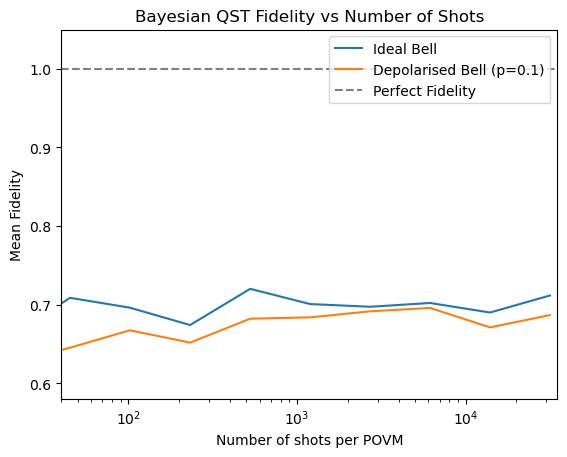

In [161]:
import matplotlib.pyplot as plt

plt.plot(N_shots_list, F_means_ideal, label='Ideal Bell')
plt.plot(N_shots_list, F_means_depol, label='Depolarised Bell (p=0.1)')
plt.xscale('log')
plt.xlabel('Number of shots per POVM')
plt.ylabel('Mean Fidelity')
plt.title('Bayesian QST Fidelity vs Number of Shots')
plt.xlim(40,35000)
plt.ylim(0.58,1.05)
plt.hlines(1.0, xmin=40, xmax=35000, colors='gray', linestyles='dashed', label='Perfect Fidelity')
plt.legend(loc='best')
plt.show()